In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))
from src.linear_regression import train_linear, test_linear
from src.preprocessing import preprocess

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### This notebook will use basic linear regression, followed by lasso linear regression, to use as a baseline for comparison with more advanced models

In [2]:
# -- Raw training data
clean_train = preprocess(pd.read_csv("../data/raw/train_raw.csv") )

# --Defining targets and model/scores dictionaries
targets = []
for col in clean_train.columns:
    if col.startswith('log_'):
        targets.append(col)
    elif clean_train[col].dtype in ['float64', 'int64']:
        # Only add raw column if no log version exists
        log_version = f'log_{col}'
        if log_version not in clean_train.columns:
            targets.append(col)
            
lin_reg_models = {}
lin_reg_scores = {}
lin_reg_data = {}

#### Linear Regression

In [3]:
# -- Linear Regression
for target in targets:
    model, scores, X, y, y_pred_cv = train_linear(clean_train, target)
    lin_reg_models[target] = model
    lin_reg_scores[target] = scores
    lin_reg_data[target] = (X, y, y_pred_cv)

In [4]:
# Iterate through both the target name and the model object
for target, model in lin_reg_models.items():
    print(f"\n--- Summary for: {target} ---")
    
    # Use the model's built-in feature names
    summary_df = pd.DataFrame({
        'Feature': model.feature_names_in_,
        'Coefficient': model.coef_
    })
    
    print(summary_df.to_string(index=False))
    print(f"Intercept: {model.intercept_:.4f}")
    
    # Optional: Print the CV score too
    mean_score = lin_reg_scores[target].mean()
    print(f"Mean CV R2: {mean_score:.4f}")


--- Summary for: LogD ---
      Feature  Coefficient
         KSOL    -0.004664
    HLM CLint    -0.000201
    MLM CLint    -0.000119
log_HLM CLint     0.176929
log_MLM CLint     0.239870
Intercept: 1.0740
Mean CV R2: 0.3214

--- Summary for: KSOL ---
      Feature  Coefficient
         LogD   -54.646606
    HLM CLint     0.023088
    MLM CLint    -0.013060
log_HLM CLint    -6.316175
log_MLM CLint    10.585573
Intercept: 226.8560
Mean CV R2: -0.0849

--- Summary for: log_HLM CLint ---
      Feature  Coefficient
         LogD     0.171766
         KSOL    -0.000523
    HLM CLint     0.005800
    MLM CLint    -0.000037
log_MLM CLint     0.210223
Intercept: 1.2471
Mean CV R2: -0.6826

--- Summary for: log_MLM CLint ---
      Feature  Coefficient
         LogD     0.326853
         KSOL     0.001231
    HLM CLint    -0.002359
    MLM CLint     0.000985
log_HLM CLint     0.295065
Intercept: 3.1809
Mean CV R2: 0.3970


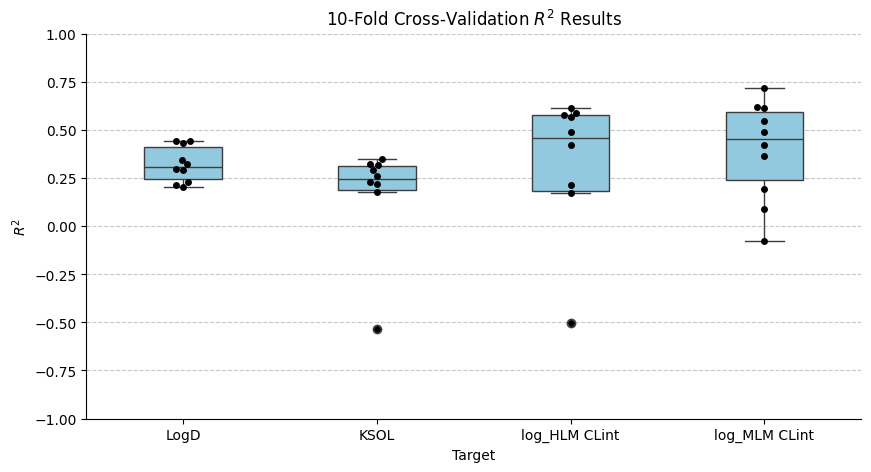

In [5]:
scores_df = pd.DataFrame(lin_reg_scores)

plt.figure(figsize=(10, 5))
sns.boxplot(data=scores_df, color='skyblue', width=0.4)
sns.swarmplot(data=scores_df, color='black')

plt.title(r'10-Fold Cross-Validation $R^2$ Results')
plt.ylabel(r'$R^2$')
plt.ylim(-1,1)
plt.xlabel('Target')
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()
plt.show()

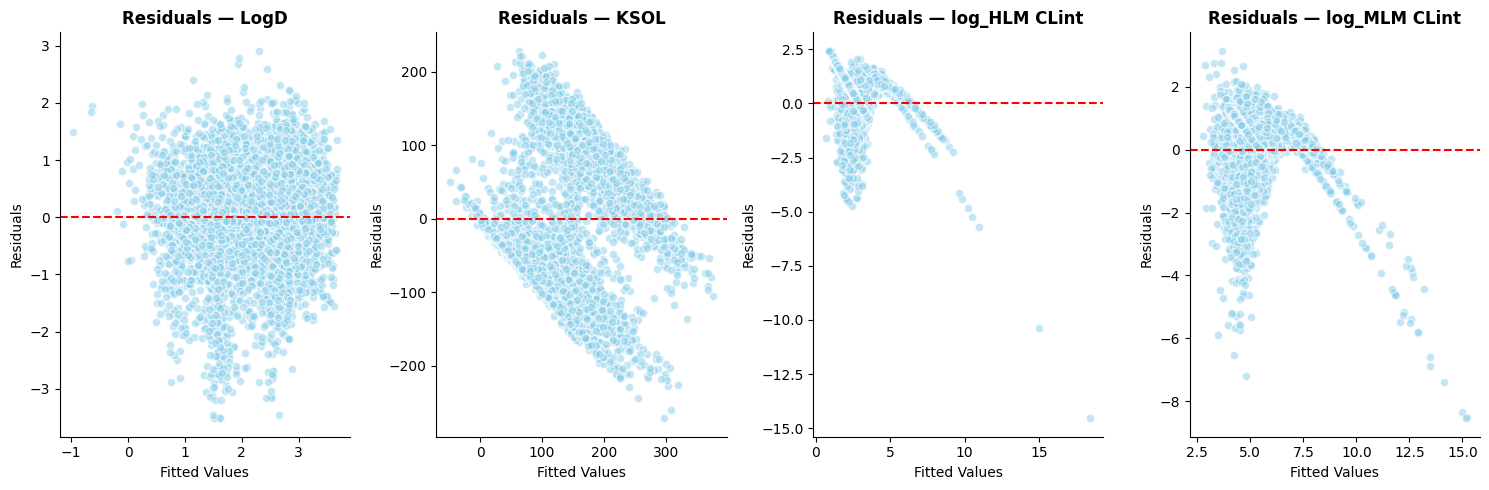

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for ax, (target, model) in zip(axes, lin_reg_models.items()):
    X, y, y_pred_cv = lin_reg_data[target]
    y_pred = model.predict(X)
    residuals = y - y_pred_cv
    ax.scatter(y_pred, residuals, alpha=0.5, color='skyblue', edgecolors='white')
    ax.axhline(y=0, color='red', linestyle='--')
    ax.set_title(f'Residuals — {target}', fontweight='bold')
    ax.set_xlabel('Fitted Values')
    ax.set_ylabel('Residuals')
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Basic linear regression residuals show heteroskedasticity, suggesting the models fail to capture non-linear relationships in the data

In [7]:
# test data
clean_test = preprocess(pd.read_csv("../data/raw/test_raw.csv"))

In [ ]:
lin_reg_pred = {} #dictionary to hold the predictions from each model

for target in lin_reg_models.keys():
    #predict each target using its respective trained linear regression model and store results in the lin_reg_pred dictionary
    lin_reg_pred[target] = test_linear(clean_test,target, lin_reg_models[target])

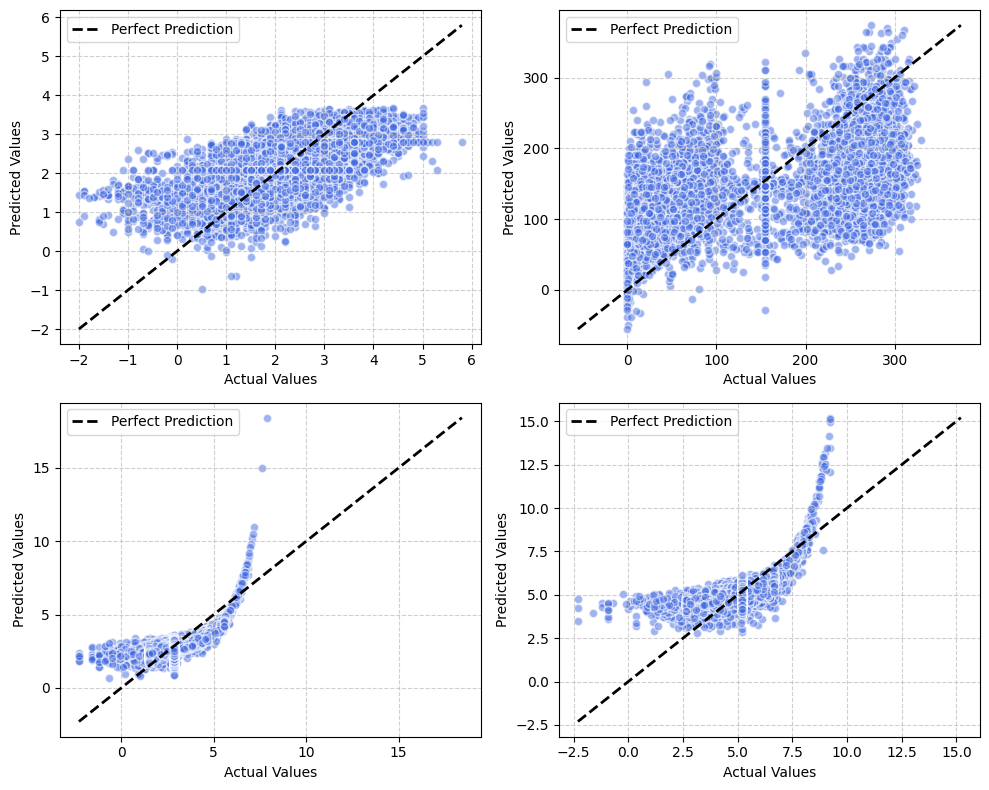

In [ ]:
# Plot test results for each model
fig, axs = plt.subplots(2, 2, figsize=(10, 8)) #Set axis
axs_flat = axs.flatten()  #flatten to use in loop

for i, target in enumerate(lin_reg_pred.keys()):
    ax = axs_flat[i]
    y_pred = lin_reg_pred[target]
    y_real = clean_test[target]
    ax.scatter(y_real, y_pred, alpha=0.5, color='royalblue', edgecolors='w')

    min_val = min(min(y_real), min(y_pred))
    max_val = max(max(y_real), max(y_pred))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction') #line representing perfect prediction

    ax.set_xlabel('Actual Values')
    ax.set_ylabel('Predicted Values')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

plt.tight_layout()
plt.show()